In [1]:
import torch
from torch_geometric.loader import DataLoader
from torch_geometric.data import Batch
import torch_geometric.transforms as T
from torch_geometric.transforms import FixedPoints, KNNGraph, RadiusGraph
# from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
from tqdm import tqdm

import os
import os.path as osp

import sys
sys.path.append('src/')
from interface_dataset import InterfaceDataset
from transform import DivideByHeight, CenterViaPBC

sys.path.append('model/')
from PointNet import PointNet

---

In [4]:
dataset = InterfaceDataset(root=osp.join('data/InterfaceDataset'))

In [5]:
dataset.transform = T.Compose([
    CenterViaPBC(),
    DivideByHeight(),
    FixedPoints(num=512),
    KNNGraph(k=6),
    # RadiusGraph(r=0.1),
])

<function matplotlib.pyplot.show(close=None, block=None)>

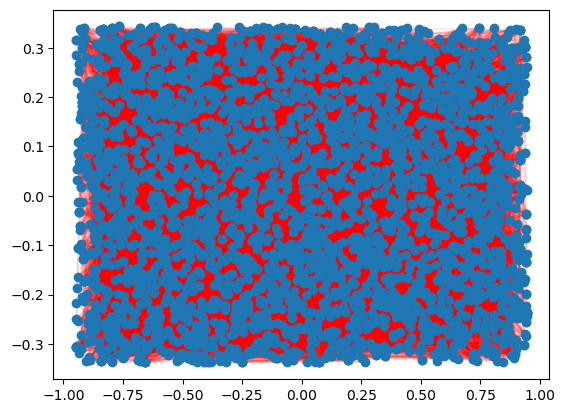

In [23]:
i = 0
pos = dataset[i].pos
edge_index = dataset[i].edge_index
x = 0
y = 2

for id in range(dataset[0].edge_index.size()[1]):
    i = edge_index[0, id]
    j = edge_index[1, id]
    plt.plot([pos[i, x], pos[j, x]], [pos[i, y], pos[j, y]], color='red', alpha=0.1, zorder=1)

plt.scatter(pos[:, x], pos[:, y], zorder=2)
plt.show

In [6]:
train_dataset, test_dataset = torch.utils.data.random_split(dataset, [0.8, 0.2])

In [7]:
batch_size = 32

train_loader = DataLoader(train_dataset.indices, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset.indices, batch_size=batch_size)

In [8]:
device = "cuda:1" if torch.cuda.is_available() else "cpu"
device

'cuda:1'

In [9]:
model = PointNet(num_classes=6).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = torch.nn.CrossEntropyLoss()

In [10]:
def train():
    model.train()

    total_loss = 0
    for data_indices in tqdm(train_loader, desc='Train'):
        data = Batch.from_data_list(dataset[data_indices]).to(device)

        optimizer.zero_grad()
        logits = model(data.pos, data.edge_index, data.batch)
        loss = criterion(logits, data.y)
        loss.backward()
        optimizer.step()
        total_loss += float(loss) * data.num_graphs

    return total_loss / len(train_loader.dataset)

In [11]:
@torch.no_grad()
def test():
    model.eval()

    total_correct = 0
    for data_indices in tqdm(test_loader, desc='Test'):
        data = Batch.from_data_list(dataset[data_indices]).to(device)

        logits = model(data.pos, data.edge_index, data.batch)
        pred = logits.argmax(dim=-1)
        total_correct += int((pred == data.y).sum())

    return total_correct / len(test_loader.dataset)

In [ ]:
Loss_train = []
Loss_test = []

In [14]:
for epoch in range(1, 11):
    print(f'Epoch: {epoch:02d}')
    loss = train()
    test_acc = test()
    print(f'Loss: {loss:.4f}, Test Acc: {test_acc:.4f}')

    Loss_train.append(loss)
    Loss_test.append(test_acc)

Epoch: 01


Test: 100%|██████████| 433/433 [00:35<00:00, 12.23it/s]


Loss: 0.1652, Test Acc: 0.9129
Epoch: 02


Test: 100%|██████████| 433/433 [00:34<00:00, 12.50it/s]


Loss: 0.1598, Test Acc: 0.9510
Epoch: 03


...

Loss: 0.1510, Test Acc: 0.9471
Epoch: 09


Test: 100%|██████████| 433/433 [00:34<00:00, 12.56it/s]


Loss: 0.1463, Test Acc: 0.9550
Epoch: 10


Test: 100%|██████████| 433/433 [00:34<00:00, 12.38it/s]

Loss: 0.1465, Test Acc: 0.9592


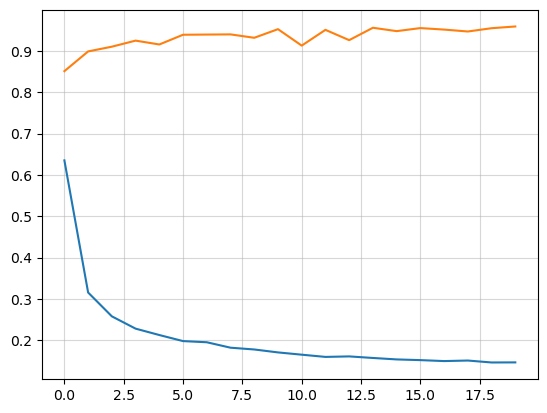

In [16]:
plt.grid(alpha=0.5)
plt.plot(Loss_train)
plt.plot(Loss_test)

In [11]:
torch.save(model.state_dict(), 'pointnet_1024.pt')